## Filter by AA Runs

In [3]:
import re
import subprocess
import os

# Check if the sequence contains more than `max_repeats` of the same character in a row
def has_repeated_chars(sequence, max_repeats=3):
    pattern = re.compile(r"(.)\1{" + str(max_repeats) + ",}")
    return pattern.search(sequence) is not None

def filter_sequences(input_file, output_file):
    with open(input_file, 'r') as infile, open(output_file, 'w') as outfile:
        entry_name = ""
        sequence = ""
        write_entry = False
        
        for line in infile:
            if line.startswith('>'):
                # Write the previous entry if it's valid
                if entry_name and sequence and not has_repeated_chars(sequence):
                    outfile.write(entry_name + '\n')
                    outfile.write(sequence + '\n')
                # Start a new entry
                entry_name = line.strip()
                sequence = ""
            else:
                sequence += line.strip()
        
        # Write the last entry if it's valid
        if entry_name and sequence and not has_repeated_chars(sequence):
            outfile.write(entry_name + '\n')
            outfile.write(sequence + '\n')

if __name__ == "__main__":
    input_path = "/user/work/dy19627/LigandMPNN_v2/outputs/seq42_empty/v2/seqs/"
    input_file = "e4d2_seq42_apo_E149C.fa"
    output_file = input_path + input_file.replace(".fa", "_aa_filt.fa")
    filter_sequences(input_path + input_file, output_file)
    print("Input File:", input_path + input_file)
    print("Output File:", output_file)

#sed_command = ["sed", "-i", "0~2s/.\\{36\\}/&C/", output_file]
#subprocess.run(sed_command)

Input File: /user/work/dy19627/LigandMPNN_v2/outputs/seq42_empty/v2/seqs/e4d2_seq42_apo_E149C.fa
Output File: /user/work/dy19627/LigandMPNN_v2/outputs/seq42_empty/v2/seqs/e4d2_seq42_apo_E149C_aa_filt.fa


## (Skip Filtering Step)

In [ ]:
import os

input_path = os.getcwd()+"/seq42_empty/v1/seqs"
input_file = "e4d2_sol1_seq42_apo.fa"

## ProtParam

In [4]:
import os
import pandas as pd
import subprocess
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqIO import FastaIO

# Path to your FASTA file
fasta_file = input_path+input_file[:-3]+"_aa_filt.fa"

# Function to extract values from the sequence description
def extract_values(description):
    try:
        parts = description.split(', ')
        seq_rec = float(parts[6].split('=')[1])
        overall_confidence = float(parts[4].split('=')[1])
        ligand_confidence = float(parts[5].split('=')[1])
        return seq_rec, overall_confidence, ligand_confidence
    except (IndexError, ValueError) as e:
        print(f"Error parsing description: {description}")
        print(f"Error: {e}")
        return None, None, None

# List to store results
results = []
seq_records = []  # List to store sequence records

# Parse the FASTA file and compute protein parameters for each sequence
for record in SeqIO.parse(fasta_file, "fasta"):
    seq_id = record.description.split(', ')[1].split('=')[1]  # Extract the id
    seq_rec, overall_confidence, ligand_confidence = extract_values(record.description)
    
    if seq_rec is None or overall_confidence is None or ligand_confidence is None:
        continue  # Skip this record if there was an error

    seq = str(record.seq)
    analysis = ProteinAnalysis(seq)
    
    # Compute various protein parameters
    pi = analysis.isoelectric_point()
    molecular_weight = analysis.molecular_weight()
    aromaticity = analysis.aromaticity()
    instability_index = analysis.instability_index()
    gravy = analysis.gravy()
    secondary_structure_fraction = analysis.secondary_structure_fraction()
    amino_acid_percent = analysis.get_amino_acids_percent()
    amino_acid_count = analysis.count_amino_acids()
    extinction_coefficient = analysis.molar_extinction_coefficient()

    # Append results to the list
    results.append({
        "ID": seq_id,
        "Seq Rec": seq_rec,
        "Overall Confidence": overall_confidence,
        "Ligand Confidence": ligand_confidence,
        "Isoelectric Point": pi,
        "Molecular Weight": molecular_weight,
        "Aromaticity": aromaticity,
        "Instability Index": instability_index,
        "GRAVY": gravy,
        "Helix Fraction": secondary_structure_fraction[0],
        "Turn Fraction": secondary_structure_fraction[1],
        "Sheet Fraction": secondary_structure_fraction[2],
        "Extinction Coefficient (reduced)": extinction_coefficient[0],
        "Extinction Coefficient (oxidized)": extinction_coefficient[1],
    })
    
    # Store the sequence record for later use
    seq_records.append(record)

# Create a DataFrame
df = pd.DataFrame(results)
print("DataFrame columns:", df.columns)  # Debug statement to check columns

# Find min and max for normalization
overall_conf_min = df['Overall Confidence'].min()
overall_conf_max = df['Overall Confidence'].max()
ligand_conf_min = df['Ligand Confidence'].min()
ligand_conf_max = df['Ligand Confidence'].max()

# Function to normalize values
def normalize(value, min_val, max_val):
    return (value - min_val) / (max_val - min_val)

# Normalize the "Overall Confidence" and "Ligand Confidence" columns
df['Normalized Overall Confidence'] = df['Overall Confidence'].apply(normalize, args=(overall_conf_min, overall_conf_max))
#df['Normalized Ligand Confidence'] = df['Ligand Confidence'].apply(normalize, args=(ligand_conf_min, ligand_conf_max))

# Calculate the average of the normalized values
df['Average Normalized Confidence'] = df[['Normalized Overall Confidence']].mean(axis=1)

# Calculate the average for each numeric column and add it as a new row
average_row = {col: df[col].mean() if df[col].dtype in ['float64', 'int64'] else 'Average' for col in df.columns}

# Convert the average_row dictionary into a DataFrame
average_df = pd.DataFrame([average_row])

# Concatenate the original DataFrame with the average row
df = pd.concat([df, average_df], ignore_index=True)

output_file = fasta_file.replace('.fa', '_conf_protparam_normalized.csv')

# Save to CSV
df.to_csv(output_file, index=False)

# Get the top 10 sequences based on "Average Normalized Confidence"
top_10_df = df.nlargest(10, 'Average Normalized Confidence')

# Create a new FASTA file with the top 10 sequences
top_10_fasta_file = fasta_file.replace('.fa', '_top_10.fa')

with open(top_10_fasta_file, 'w') as output_handle:
    fasta_writer = FastaIO.FastaWriter(output_handle, wrap=None)  # Set wrap=None to avoid line breaks
    fasta_writer.write_header()
    for seq_id in top_10_df['ID']:
        for record in seq_records:
            if record.description.split(', ')[1].split('=')[1] == seq_id:
                fasta_writer.write_record(record)
                break
    fasta_writer.write_footer()

# Print completion message with the file path
print("Analysis complete. Results saved to " + output_file)
print("Top 10 sequences saved to " + top_10_fasta_file)
print(top_10_fasta_file)

Error parsing description: e4d2_seq42_apo_E149C, T=0.1, seed=38605, num_res=48, num_ligand_res=48, use_ligand_context=True, ligand_cutoff_distance=8.0, batch_size=250, number_of_batches=1, model_path=./model_params/proteinmpnn_v_48_020.pt
Error: could not convert string to float: 'True'
DataFrame columns: Index(['ID', 'Seq Rec', 'Overall Confidence', 'Ligand Confidence',
       'Isoelectric Point', 'Molecular Weight', 'Aromaticity',
       'Instability Index', 'GRAVY', 'Helix Fraction', 'Turn Fraction',
       'Sheet Fraction', 'Extinction Coefficient (reduced)',
       'Extinction Coefficient (oxidized)'],
      dtype='object')
Analysis complete. Results saved to /user/work/dy19627/LigandMPNN_v2/outputs/seq42_empty/v2/seqs/e4d2_seq42_apo_E149C_aa_filt_conf_protparam_normalized.csv
Top 10 sequences saved to /user/work/dy19627/LigandMPNN_v2/outputs/seq42_empty/v2/seqs/e4d2_seq42_apo_E149C_aa_filt_top_10.fa
/user/work/dy19627/LigandMPNN_v2/outputs/seq42_empty/v2/seqs/e4d2_seq42_apo_E149C

## Chai-1 Prep

In [17]:
from pathlib import Path
import re  # Import regular expression module to extract the ID and protein name

# Function to add ligands to the protein sequences in the required format
def reformat_fasta(input_fasta, output_fasta):
    # Open the input FASTA file and the output file
    with open(input_fasta, "r") as infile, open(output_fasta, "w") as outfile:
        # Read lines from the input FASTA
        lines = infile.readlines()
        
        # Define the ligands to be added for each protein
        ligands = [
            ">ligand|name=HEB1\nCC1=C(CCC(O)=O)C2=[N]3C1=Cc1c(C)c(C=C)c4C=C5C(C)=C(C=C)C6=[N]5[Fe]3(n14)n1c(=C6)c(C)c(CCC(O)=O)c1=C2\n",
            ">ligand|name=HEB2\nCC1=C(CCC(O)=O)C2=[N]3C1=Cc1c(C)c(C=C)c4C=C5C(C)=C(C=C)C6=[N]5[Fe]3(n14)n1c(=C6)c(C)c(CCC(O)=O)c1=C2\n",
            ">ligand|name=HEB3\nCC1=C(CCC(O)=O)C2=[N]3C1=Cc1c(C)c(C=C)c4C=C5C(C)=C(C=C)C6=[N]5[Fe]3(n14)n1c(=C6)c(C)c(CCC(O)=O)c1=C2\n"
        ]
        
        # Process each line in the FASTA file
        for line in lines:
            line = line.strip()  # Remove any extra spaces or newlines
            if line.startswith(">"):  # Look for protein headers
                # Extract the protein name and ID using a flexible regular expression
                match = re.search(r">([^,]+).*id=(\d+)", line)  # Match protein name and ID
                if match:
                    protein_name = match.group(1).strip()  # The protein name (before the first comma or space)
                    protein_id = match.group(2).strip()  # The ID number
                    
                    # Write the protein header in the required format (including ID)
                    outfile.write(f">protein|name={protein_name}_id{protein_id}\n")
                else:
                    print(f"Skipping invalid line: {line}")
            else:  # For protein sequence lines
                # Write the protein sequence
                outfile.write(f"{line}\n")
                
                # Add the ligands after the sequence
                for ligand in ligands:
                    outfile.write(ligand)
                
# Define the paths for input and output files
input_fasta = top_10_fasta_file  # Path to your current input FASTA
#output_fasta = Path("./Sol3Lig3/seqs/S3L2_HF_FMN_id96model4.fa")  # Path to output formatted FASTA
output_fasta = top_10_fasta_file[:-3] + '_processed.fa'

# Call the function to reformat the FASTA file
reformat_fasta(input_fasta, output_fasta)

print(f"Reformatted FASTA file saved as {output_fasta}")


Reformatted FASTA file saved as /user/work/dy19627/LigandMPNN_v2/outputs/seq42_3heme/v3_sol_minimal/seqs/e4D2_seq42_H4removed_aa_filt_top_10_processed.fa


In [14]:
sed -e 's/\//:/g' -e 's/[^A-Za-z0-9._>:-]/_/g' -e 's/\./-/g' input_fasta

SyntaxError: invalid syntax (2231480876.py, line 1)

## Residue Positions from FASTA File

In [30]:
def find_residue_positions(file_path):
    with open(file_path, 'r') as file:
        sequences = file.read().split('>')[1:]  # Split on '>' and skip the first empty item
    
    a_count_dict = {}  # Dictionary to count the number of sequences with a specific number of 'W's
    a_position_counts = {}  # Dictionary to count occurrences of 'W' at each position
    
    for entry in sequences:
        lines = entry.strip().split('\n')
        header = lines[0]
        sequence = ''.join(lines[1:])
        
        a_positions = [i for i, letter in enumerate(sequence) if letter == 'A']
        
        # Count the number of 'W's in the sequence
        a_count = len(a_positions)
        
        if a_count:
            print(f"Header: {header}")
        
            print(residue+f" Residue Position: {a_positions}\n")
            
            # Update the dictionary with the count of 'W's
            if a_count in a_count_dict:
                a_count_dict[a_count] += 1
            else:
                a_count_dict[a_count] = 1
            
            # Update the position counts
            for pos in a_positions:
                if pos in a_position_counts:
                    a_position_counts[pos] += 1
                else:
                    a_position_counts[pos] = 1
    
    # Print the counts of sequences with specific numbers of 'W's
    for count in sorted(a_count_dict):
        print(f"Number of sequences with {count} residue: {a_count_dict[count]}")

    # Print the counts of 'W' at each position, sorted from highest to lowest
    print("\nOccurrences of "+residue+" at each position (from highest to lowest):")
    for pos, count in sorted(a_position_counts.items(), key=lambda item: item[1], reverse=True):
        print(f"Position {pos}: {count} occurrence(s)")

# Example usage
file_path = input_path+input_file # Replace with your file path
residue='Y'
find_residue_positions(file_path)

Header: PHF_ID244_5_MD_last, T=0.1, seed=50595, num_res=45, num_ligand_res=42, use_ligand_context=True, ligand_cutoff_distance=8.0, batch_size=250, number_of_batches=1, model_path=./model_params/ligandmpnn_v_32_010_25.pt
Y Residue Position: [19, 90, 114]

Header: PHF_ID244_5_MD_last, id=1, T=0.1, seed=50595, overall_confidence=0.4917, ligand_confidence=0.4939, seq_rec=0.5778
Y Residue Position: [19, 43, 90, 93]

Header: PHF_ID244_5_MD_last, id=2, T=0.1, seed=50595, overall_confidence=0.4656, ligand_confidence=0.4674, seq_rec=0.5556
Y Residue Position: [19, 43, 90, 93]

Header: PHF_ID244_5_MD_last, id=3, T=0.1, seed=50595, overall_confidence=0.4881, ligand_confidence=0.4931, seq_rec=0.5778
Y Residue Position: [19, 90, 93]

Header: PHF_ID244_5_MD_last, id=4, T=0.1, seed=50595, overall_confidence=0.4682, ligand_confidence=0.4814, seq_rec=0.5111
Y Residue Position: [19, 90, 93]

Header: PHF_ID244_5_MD_last, id=5, T=0.1, seed=50595, overall_confidence=0.4773, ligand_confidence=0.4798, seq_r

## Plot PAE from JSON

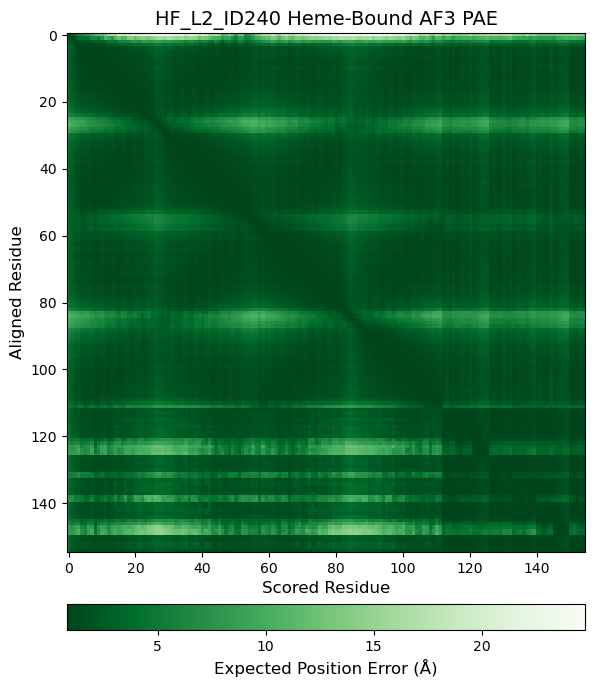

<Figure size 640x480 with 0 Axes>

In [61]:
### plot PAE from JSON
import os  
import json 
import numpy as np 
import matplotlib as mpl 
import matplotlib.pyplot as plt 
import re 

##
dpi=600 

directory = os.getcwd()+"/AF3_Models"
name="HF_L2_ID240"
##
def plot_data_from_json_files(directory): 
    # Iterate through the JSON files in the directory 
    for filename in os.listdir(directory): 
        if filename.endswith("fold_hf_v2l2_id214input_id240_full_data_0.json"): 
            file_path = os.path.join(directory, filename)  
            if os.path.isfile(file_path): 
                with open(file_path, 'r') as json_file:
                    try:
                        output = {k: np.array(v) for k, v in json.load(json_file).items()} 
                    except json.JSONDecodeError as e: 
                        print(f"Error reading {filename}: {e}") 
           
            fig, ax = plt.subplots(figsize=(10, 8))
            plt.tight_layout()
# Plot the data
            cax = ax.imshow(output["pae"], cmap="Greens_r")
# Set the title and labels
            ax.set_title(name+" AF3 PAE", size=14)
            ax.set_xlabel("Scored Residue", size=12)
            ax.set_ylabel("Aligned Residue", size=12)
# Create the colorbar below the plot
            cbar = fig.colorbar(cax, ax=ax,orientation="horizontal",pad=0.15)
            ax_pos= ax.get_position()
            # Adjust the position and size of the colorbar
            cbar.ax.set_position([ax_pos.x0, ax_pos.y0 - 0.1, ax_pos.width, 0.035])
            cbar.set_label("Expected Position Error (Å)", size=12)
            #.savefig(name+"_PAE.png", bbox_inches='tight', format="png", dpi=600) 
# Display the plot
            plt.show()
# Clear the figure
            plt.clf()
  

#directory="json_tests/" 

plot_data_from_json_files(directory)

In [44]:
import MDAnalysis as mda
from MDAnalysis.analysis.distances import distance_array

# Load the molecular structure (change to your file path)
universe = mda.Universe("/user/work/dy19627/7_NonCov_Flavin/AutodockVina/H0pt4_S4L4_ID99/S4L4_t0pt4_id99model2.pdb")

# Select the ligand and surrounding residues
ligand = universe.select_atoms("resname LIG2")
all_residues = universe.select_atoms("protein and not resname PRO GLY ALA")

# Find residues within 4 Å of the ligand
nearby_residues = set()
for residue in all_residues.residues:
    res_atoms = residue.atoms
    dists = distance_array(ligand.positions, res_atoms.positions)
    if (dists < 4.0).any():
        nearby_residues.add(residue.resid)

# Save the results
with open("/user/work/dy19627/7_NonCov_Flavin/AutodockVina/H0pt4_S4L4_ID99/nearby_residues.txt", "w") as f:
    for resid in sorted(nearby_residues):
        f.write(f"{resid}\n")

print("Residue numbers saved to nearby_residues.txt")


ModuleNotFoundError: No module named 'MDAnalysis'

## Plot Atom pLDDTs

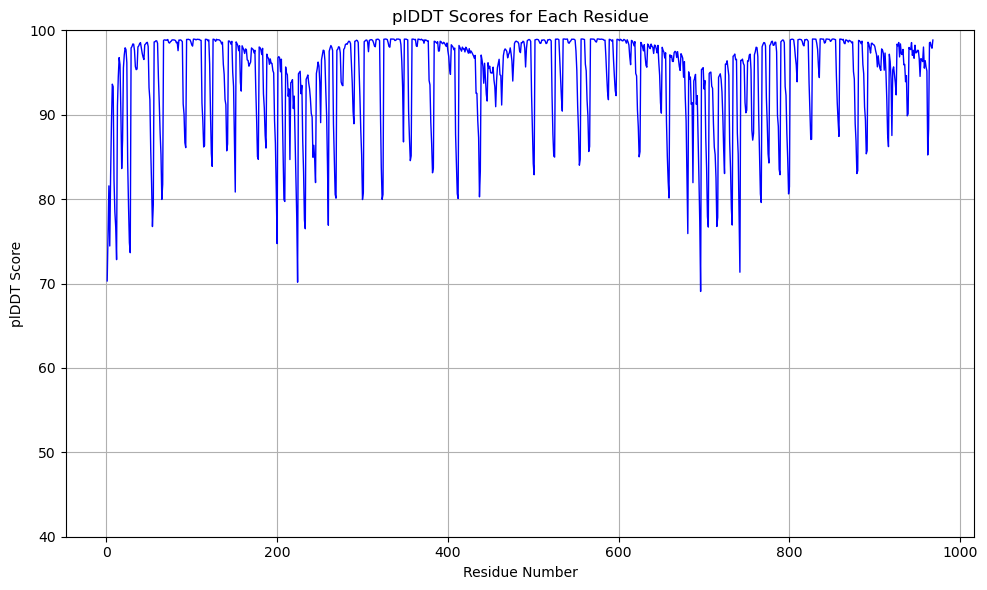

In [48]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

# Function to plot atom_plddts from JSON file
def plot_atom_plddts_from_json(file_path):
    # Open and load the JSON file
    with open(file_path, 'r') as json_file:
        data = json.load(json_file)

    # Extract 'atom_plddts' from the JSON data
    atom_plddts = np.array(data['atom_plddts'])
    
    # Create a range for x-axis based on the number of atom_plddts
    residues = np.arange(1, len(atom_plddts) + 1)

    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(residues, atom_plddts, color='blue', linewidth=1)
    plt.ylim(40,100)
    
    # Adding labels and title
    plt.xlabel('Residue Number')
    plt.ylabel('plDDT Score')
    plt.title('plDDT Scores for Each Residue')

    # Show a grid for better readability
    plt.grid(True)

    # Display the plot
    plt.tight_layout()
    plt.show()

# Define the path to your JSON file
directory = os.getcwd()+"/AF3_Models"
json_file_path = os.path.join(directory, 'fold_hf_v2l2_id214input_id240_full_data_0.json')  # Change this to your file name

# Call the function to plot the data
plot_atom_plddts_from_json(json_file_path)
